# Machine Learning Theory

> **Main references:**
> - Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
> - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
> - Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press.

---

## Study Roadmap

| # | Topic |
|---|-------|
| 1 | Probabilistic Foundations |
| 2 | Supervised Learning — Probabilistic View |
| 3 | Unsupervised Learning — Probabilistic View |
| 4 | Capacity, Underfitting and Overfitting |
| 5 | Training Error and Generalization Error |
| 6 | Bayes Error |
| 7 | Parameter Estimation, Bias and Variance |
| 8 | Relating Error, Bias and Variance |
| 9 | Maximum Likelihood Estimation (MLE) |
| 10 | Bayesian Statistics |


In [1]:
# Installation / general imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
import scipy.stats as stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(42)
print('Libraries loaded successfully.')

Bibliotecas carregadas com sucesso.


---
## 1. Probabilistic Foundations

### 1.1 Probability Distributions

Machine learning is, at its core, a problem of **probabilistic inference**.
We need a few base concepts before going further.

**Joint, marginal and conditional probability:**

$$P(X, Y) = P(Y \mid X)\,P(X) = P(X \mid Y)\,P(Y)$$

**Bayes' rule** (fundamental for everything that follows):

$$\boxed{P(Y \mid X) = \frac{P(X \mid Y)\,P(Y)}{P(X)}}$$

where:
- $P(Y \mid X)$ — **posterior**: belief about $Y$ after observing $X$
- $P(X \mid Y)$ — **likelihood**: how probable $X$ is given $Y$
- $P(Y)$ — **prior**: prior belief about $Y$
- $P(X)$ — **evidence**: normalizer (marginal of $X$)

**Expectation and Variance:**

$$\mathbb{E}[X] = \int x\,p(x)\,dx \qquad \text{Var}(X) = \mathbb{E}\!\left[(X - \mathbb{E}[X])^2\right]$$


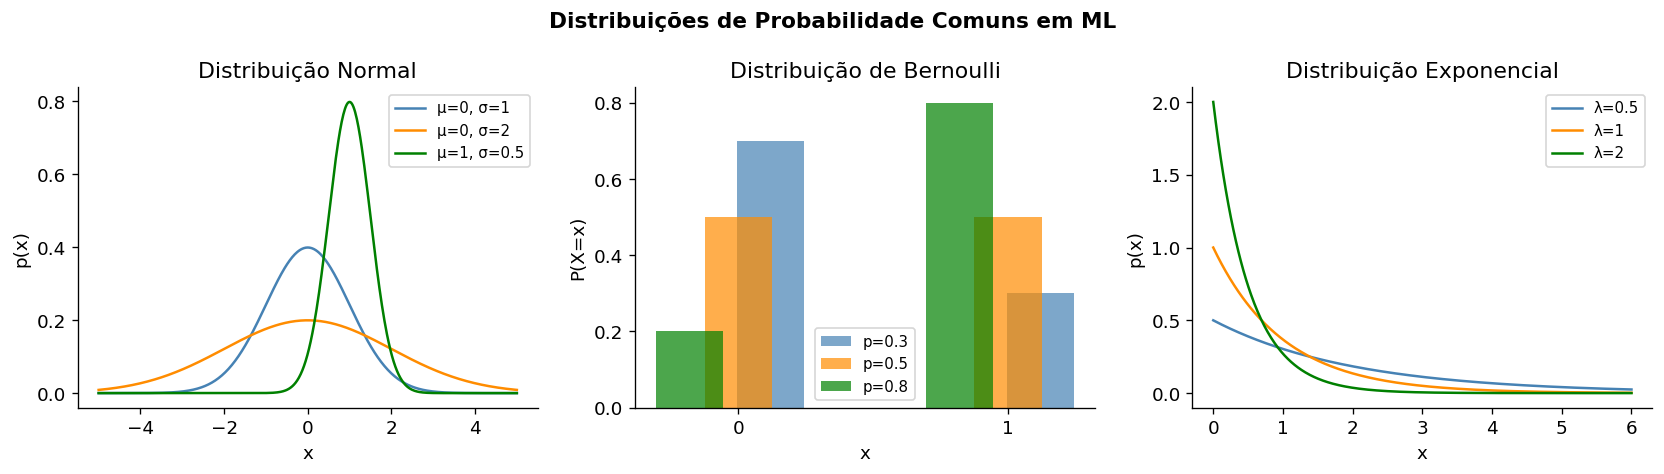

In [2]:
# --- Visualizing common ML distributions ---
x = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gaussian
for mu, sigma, c in [(0, 1, 'steelblue'), (0, 2, 'darkorange'), (1, 0.5, 'green')]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma),
                 label=f'μ={mu}, σ={sigma}', color=c)
axes[0].set_title('Normal Distribution')
axes[0].set_xlabel('x'); axes[0].set_ylabel('p(x)')
axes[0].legend(fontsize=9)

# Bernoulli
for p, c in [(0.3, 'steelblue'), (0.5, 'darkorange'), (0.8, 'green')]:
    axes[1].bar([0 - 0.2*(p-0.5)*3, 1 - 0.2*(p-0.5)*3], [1-p, p],
                width=0.25, alpha=0.7, label=f'p={p}', color=c)
axes[1].set_title('Bernoulli Distribution')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['0', '1'])
axes[1].set_xlabel('x'); axes[1].set_ylabel('P(X=x)')
axes[1].legend(fontsize=9)

# Exponential
x_exp = np.linspace(0, 6, 500)
for lam, c in [(0.5, 'steelblue'), (1, 'darkorange'), (2, 'green')]:
    axes[2].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam),
                 label=f'λ={lam}', color=c)
axes[2].set_title('Exponential Distribution')
axes[2].set_xlabel('x'); axes[2].set_ylabel('p(x)')
axes[2].legend(fontsize=9)

plt.suptitle('Common Probability Distributions in ML', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Supervised Learning — Probabilistic View

### 2.1 Formal Definition

Given a training set $\mathcal{D} = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{N}$, where:

- $\mathbf{x}^{(i)} \in \mathcal{X}$ — feature vector
- $y^{(i)} \in \mathcal{Y}$ — label or target value

We assume the data were generated by an **unknown joint distribution** $p^*(\mathbf{x}, y)$.

### 2.2 Probabilistic Modeling

**Discriminative approach** — models $p(y \mid \mathbf{x}; \boldsymbol{\theta})$ directly:

$$\hat{y} = \arg\max_{y} \; p(y \mid \mathbf{x}; \boldsymbol{\theta})$$

**Generative approach** — models $p(\mathbf{x}, y; \boldsymbol{\theta}) = p(\mathbf{x} \mid y)\,p(y)$ and uses Bayes' rule to obtain $p(y \mid \mathbf{x})$.

### 2.3 Regression as a Probabilistic Problem

For regression, we assume:

$$y = f(\mathbf{x}; \boldsymbol{\theta}) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Equivalently:

$$p(y \mid \mathbf{x}; \boldsymbol{\theta}) = \mathcal{N}\!\left(y; f(\mathbf{x}; \boldsymbol{\theta}), \sigma^2\right)$$

**Minimizing the MSE is equivalent to maximizing the likelihood under Gaussian noise.**


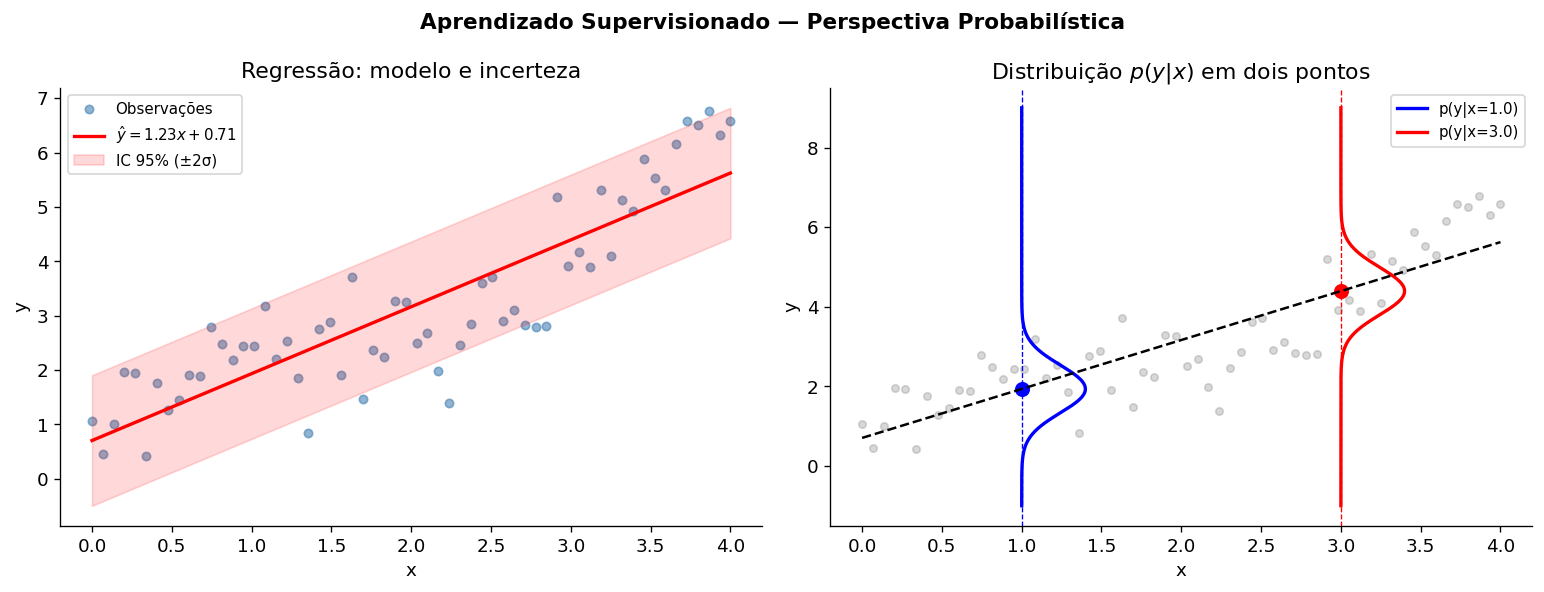

In [3]:
# --- Regression as probabilistic inference ---

np.random.seed(0)
n = 60
X_true = np.linspace(0, 4, n)
sigma_noise = 0.6
y_true = 1.5 * X_true + 0.8 * np.sin(2 * X_true)
y_obs = y_true + np.random.normal(0, sigma_noise, n)

# Simple linear fit
coeffs = np.polyfit(X_true, y_obs, 1)
y_pred = np.polyval(coeffs, X_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: data + model + uncertainty
axes[0].scatter(X_true, y_obs, alpha=0.6, s=25, label='Observations', color='steelblue')
axes[0].plot(X_true, y_pred, 'r-', lw=2, label=f'$\\hat{{y}} = {coeffs[0]:.2f}x + {coeffs[1]:.2f}$')
axes[0].fill_between(X_true, y_pred - 2*sigma_noise, y_pred + 2*sigma_noise,
                     alpha=0.15, color='red', label='95% CI (±2σ)')
axes[0].set_title('Regression: model and uncertainty')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(fontsize=9)

# Right: distribution p(y|x) at two points
y_range = np.linspace(-1, 9, 300)
for x_pt, c in [(1.0, 'blue'), (3.0, 'red')]:
    mu_pt = np.polyval(coeffs, x_pt)
    pdf = stats.norm.pdf(y_range, mu_pt, sigma_noise)
    axes[1].plot(pdf * 0.6 + x_pt, y_range, color=c, lw=2,
                 label=f'p(y|x={x_pt})')
    axes[1].axvline(x_pt, color=c, lw=0.8, ls='--')
    axes[1].plot(x_pt, mu_pt, 'o', color=c, ms=8)

axes[1].scatter(X_true, y_obs, alpha=0.3, s=20, color='gray')
axes[1].plot(X_true, y_pred, 'k--', lw=1.5)
axes[1].set_title('Distribution $p(y|x)$ at two points')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend(fontsize=9)

plt.suptitle('Supervised Learning — Probabilistic Perspective', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Classification as a Probabilistic Problem

For binary classification, we use the **Bernoulli** distribution:

$$p(y \mid \mathbf{x}; \boldsymbol{\theta}) = \sigma(f(\mathbf{x}; \boldsymbol{\theta}))^y \cdot [1 - \sigma(f(\mathbf{x}; \boldsymbol{\theta}))]^{1-y}$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the **sigmoid** (logistic) function.

**Cross-entropy** emerges naturally as the loss function when we maximize the likelihood:

$$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y^{(i)}\log \hat{p}^{(i)} + (1-y^{(i)})\log(1-\hat{p}^{(i)})\right]$$


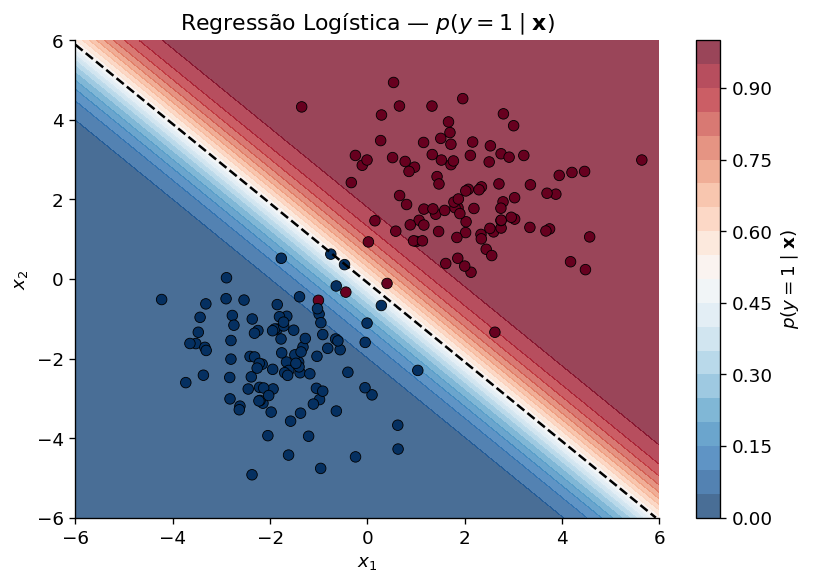

In [4]:
# --- Logistic Regression: class probability ---
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

X_cls, y_cls = make_blobs(n_samples=200, centers=[[-2, -2], [2, 2]],
                           cluster_std=1.2, random_state=1)

clf = LogisticRegression().fit(X_cls, y_cls)

xx, yy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.75)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5,
           linestyles='--')
scatter = ax.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu_r',
                     edgecolors='k', s=40, linewidths=0.5)
plt.colorbar(cf, ax=ax, label='$p(y=1 \\mid \\mathbf{x})$')
ax.set_title('Logistic Regression — $p(y=1 \\mid \\mathbf{x})$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

---
## 3. Unsupervised Learning — Probabilistic View

### 3.1 Definition

In unsupervised learning we have only $\mathcal{D} = \{\mathbf{x}^{(i)}\}_{i=1}^{N}$ **without labels**.

The goal is to learn the **latent structure** of the data — i.e. find a model $p(\mathbf{x}; \boldsymbol{\theta})$ that captures the regularities of the generating distribution.

### 3.2 Gaussian Mixture Models (GMM)

A central probabilistic model for clustering is the **Gaussian Mixture Model**:

$$p(\mathbf{x}; \boldsymbol{\theta}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where:
- $K$ — number of components (clusters)
- $\pi_k$ — mixture weight ($\sum_k \pi_k = 1$, $\pi_k \ge 0$)
- $\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k$ — mean and covariance of the $k$-th Gaussian

The latent variable $z \in \{1,\ldots,K\}$ indicates which component generated $\mathbf{x}$:

$$p(z = k) = \pi_k, \qquad p(\mathbf{x} \mid z = k) = \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

The **EM (Expectation-Maximization)** algorithm maximizes the marginal log-likelihood by alternating:
- **E-step:** compute the responsibilities $r_{ik} = p(z=k \mid \mathbf{x}^{(i)})$
- **M-step:** update the parameters $\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k$


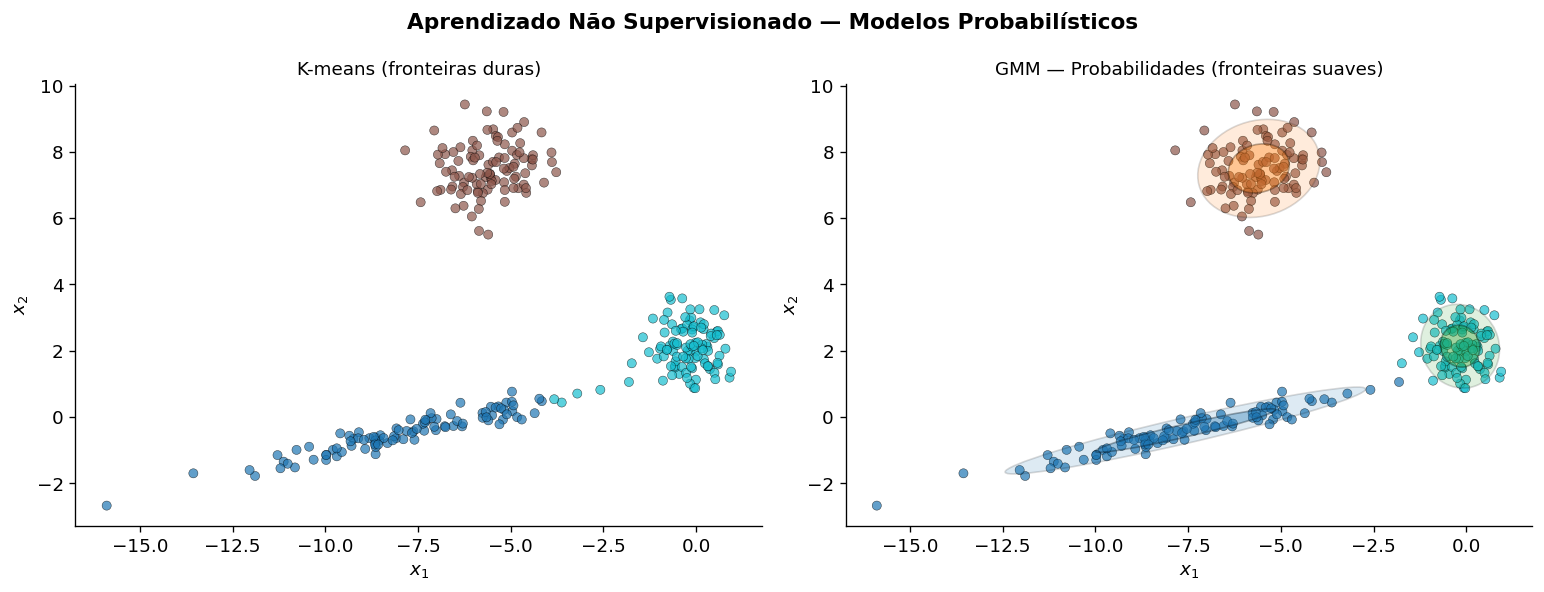

In [5]:
# --- GMM vs K-means: probabilistic perspective ---
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

np.random.seed(5)
blobs, blob_labels = make_blobs(n_samples=300, centers=3, cluster_std=[0.8, 1.2, 0.6],
                                 random_state=5)
# stretch one cluster to test covariance
blobs[blob_labels == 1] = blobs[blob_labels == 1] @ np.array([[2, 0.5],[0.5, 0.3]])

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(blobs)
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto').fit(blobs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
titles = ['K-means (hard boundaries)', 'GMM — Probabilities (soft boundaries)']
labels_list = [kmeans.labels_, gmm.predict(blobs)]
colors = plt.cm.tab10(np.array([0, 1, 2]))

for ax, lbl, title in zip(axes, labels_list, titles):
    ax.scatter(blobs[:, 0], blobs[:, 1], c=lbl, cmap='tab10', s=30,
               alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# GMM confidence ellipses
from matplotlib.patches import Ellipse
for k in range(3):
    mu = gmm.means_[k]
    cov = gmm.covariances_[k]
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    for n_std, alpha in [(1, 0.35), (2, 0.15)]:
        width, height = 2 * n_std * np.sqrt(vals)
        ell = Ellipse(mu, width, height, angle=angle,
                      facecolor=colors[k], alpha=alpha, edgecolor='k', lw=1)
        axes[1].add_patch(ell)

plt.suptitle('Unsupervised Learning — Probabilistic Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Model Capacity, Underfitting and Overfitting

### 4.1 Capacity (Complexity) of a Model

The **capacity** of a model is its ability to fit a wide variety of functions.
Formally, it can be measured by the **Vapnik-Chervonenkis (VC) dimension**:

> The VC dimension of a classifier is the largest number of points it can classify correctly under **all** $2^n$ possible binary labelings.

### 4.2 Underfitting and Overfitting

| Situation | Training error | Test error | Cause |
|-----------|----------------|------------|-------|
| **Underfitting** | High | High | Insufficient capacity; model misses the pattern |
| **Good fit** | Low | Low | Correct capacity |
| **Overfitting** | Very low | High | Excessive capacity; model memorizes the noise |

**Occam's razor:** prefer the simplest model that explains the data well.

### 4.3 Regularization

To control overfitting, we add a penalty term to the cost:

$$\mathcal{L}_{\text{reg}}(\boldsymbol{\theta}) = \mathcal{L}(\boldsymbol{\theta}) + \lambda \Omega(\boldsymbol{\theta})$$

- **Ridge ($L_2$):** $\Omega(\boldsymbol{\theta}) = \|\boldsymbol{\theta}\|_2^2$ → shrinks weights
- **Lasso ($L_1$):** $\Omega(\boldsymbol{\theta}) = \|\boldsymbol{\theta}\|_1$ → sparsity


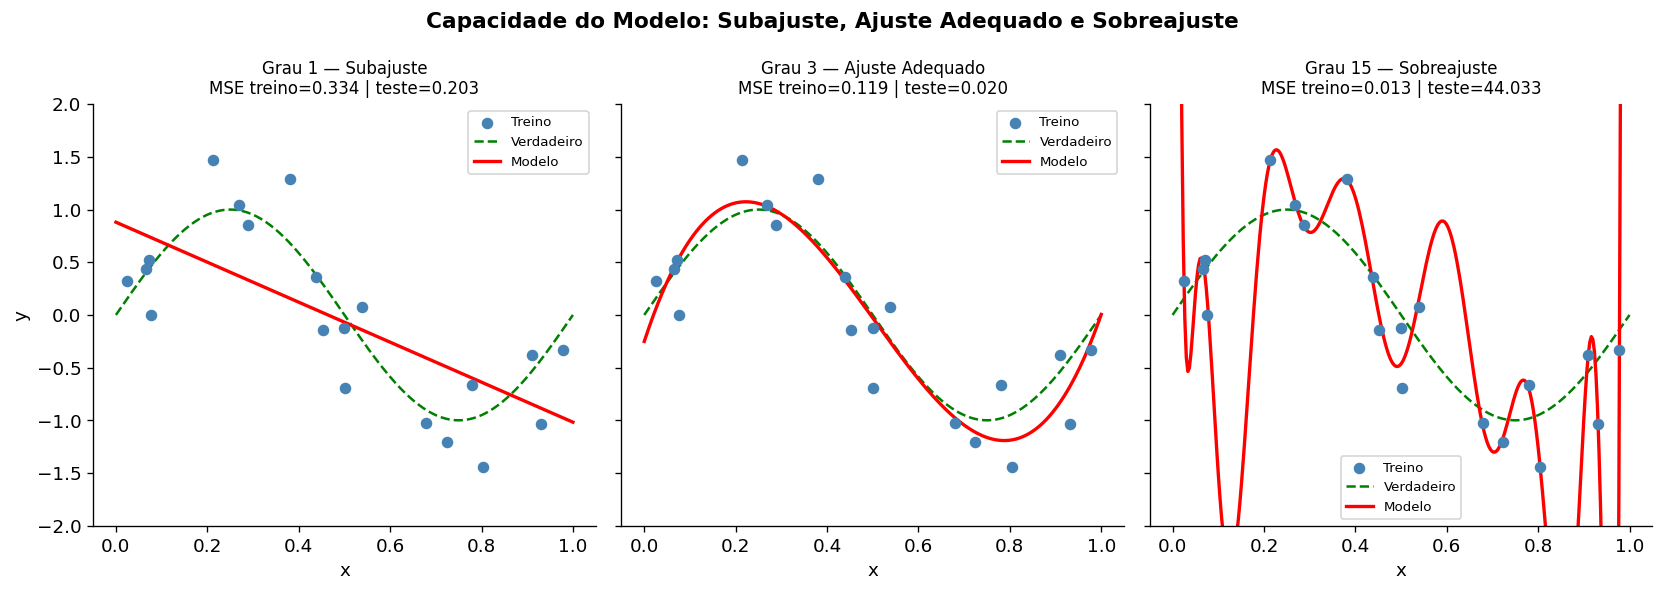

In [6]:
# --- Polynomial regression: underfitting, good fit, overfitting ---

np.random.seed(7)
n_train = 20
X_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = np.sin(2 * np.pi * X_train) + np.random.normal(0, 0.3, n_train)

X_test = np.linspace(0, 1, 300)
y_true_test = np.sin(2 * np.pi * X_test)

degrees = [1, 3, 15]
titles_deg = ['Degree 1 — Underfitting', 'Degree 3 — Good Fit', 'Degree 15 — Overfitting']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, deg, title in zip(axes, degrees, titles_deg):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_train.reshape(-1, 1), y_train)
    y_pred_test = model.predict(X_test.reshape(-1, 1))
    y_pred_train = model.predict(X_train.reshape(-1, 1))
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_true_test, y_pred_test)
    
    ax.scatter(X_train, y_train, s=35, color='steelblue', zorder=3, label='Train')
    ax.plot(X_test, y_true_test, 'g--', lw=1.5, label='True')
    ax.plot(X_test, y_pred_test, 'r-', lw=2, label='Model')
    ax.set_ylim(-2, 2)
    ax.set_title(f'{title}\nMSE train={mse_train:.3f} | test={mse_test:.3f}', fontsize=10)
    ax.set_xlabel('x')
    ax.legend(fontsize=8)

axes[0].set_ylabel('y')
plt.suptitle('Model Capacity: Underfitting, Good Fit and Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

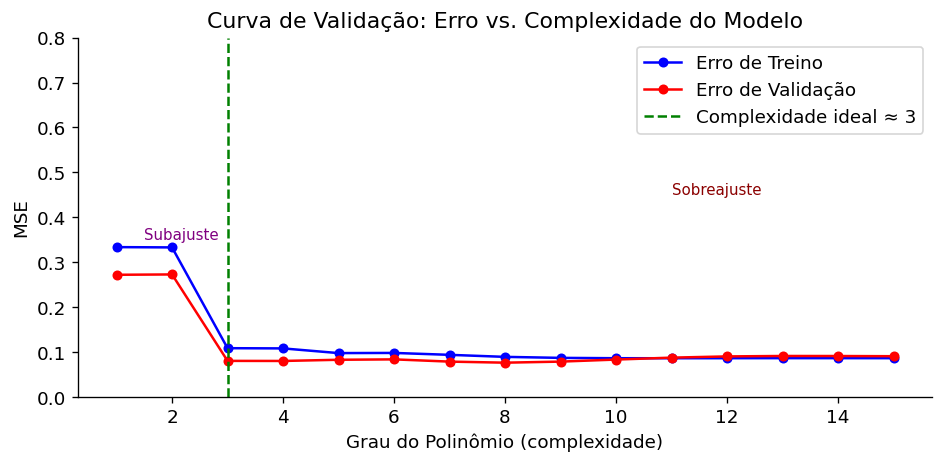

In [7]:
# --- Validation curve: error vs. complexity ---

np.random.seed(3)
N = 60
X_all = np.sort(np.random.uniform(0, 1, N))
y_all = np.sin(2 * np.pi * X_all) + np.random.normal(0, 0.3, N)
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.4, random_state=1)

degrees_range = range(1, 16)
mse_train_list, mse_val_list = [], []

for deg in degrees_range:
    m = make_pipeline(PolynomialFeatures(deg), Ridge(alpha=1e-6))
    m.fit(X_tr.reshape(-1, 1), y_tr)
    mse_train_list.append(mean_squared_error(y_tr, m.predict(X_tr.reshape(-1, 1))))
    mse_val_list.append(mean_squared_error(y_val, m.predict(X_val.reshape(-1, 1))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees_range, mse_train_list, 'b-o', ms=5, label='Training Error')
ax.plot(degrees_range, mse_val_list, 'r-o', ms=5, label='Validation Error')
ax.axvline(3, color='green', ls='--', lw=1.5, label='Ideal complexity ≈ 3')
ax.annotate('Underfitting', xy=(1.5, 0.35), fontsize=9, color='purple')
ax.annotate('Overfitting', xy=(11, 0.45), fontsize=9, color='darkred')
ax.set_xlabel('Polynomial Degree (complexity)')
ax.set_ylabel('MSE')
ax.set_ylim(0, 0.8)
ax.set_title('Validation Curve: Error vs. Model Complexity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Training Error and Generalization Error

### 5.1 Formal Definitions

Let $\ell(y, \hat{y})$ be a loss function (e.g. squared error $\ell = (y - \hat{y})^2$).

**True risk** (generalization error):

$$R(f) = \mathbb{E}_{(\mathbf{x}, y) \sim p^*}[\ell(y, f(\mathbf{x}))] = \int \ell(y, f(\mathbf{x}))\, p^*(\mathbf{x}, y)\, d\mathbf{x}\, dy$$

**Empirical risk** (training error):

$$\hat{R}(f) = \frac{1}{N} \sum_{i=1}^{N} \ell\!\left(y^{(i)}, f(\mathbf{x}^{(i)})\right)$$

By the **Law of Large Numbers**: $\hat{R}(f) \xrightarrow{N \to \infty} R(f)$.

### 5.2 Generalization Gap

$$\text{Gap} = R(f) - \hat{R}(f)$$

The **Empirical Risk Minimization (ERM)** principle seeks:

$$f^* = \arg\min_{f \in \mathcal{F}} \hat{R}(f)$$

### 5.3 Generalization Bounds

With probability $\ge 1 - \delta$ (over samples of size $N$):

$$R(f) \le \hat{R}(f) + \mathcal{O}\!\left(\sqrt{\frac{\text{VC}(\mathcal{F}) + \log(1/\delta)}{N}}\right)$$

**Implication:** more data $\Rightarrow$ smaller gap; higher capacity $\Rightarrow$ larger gap.


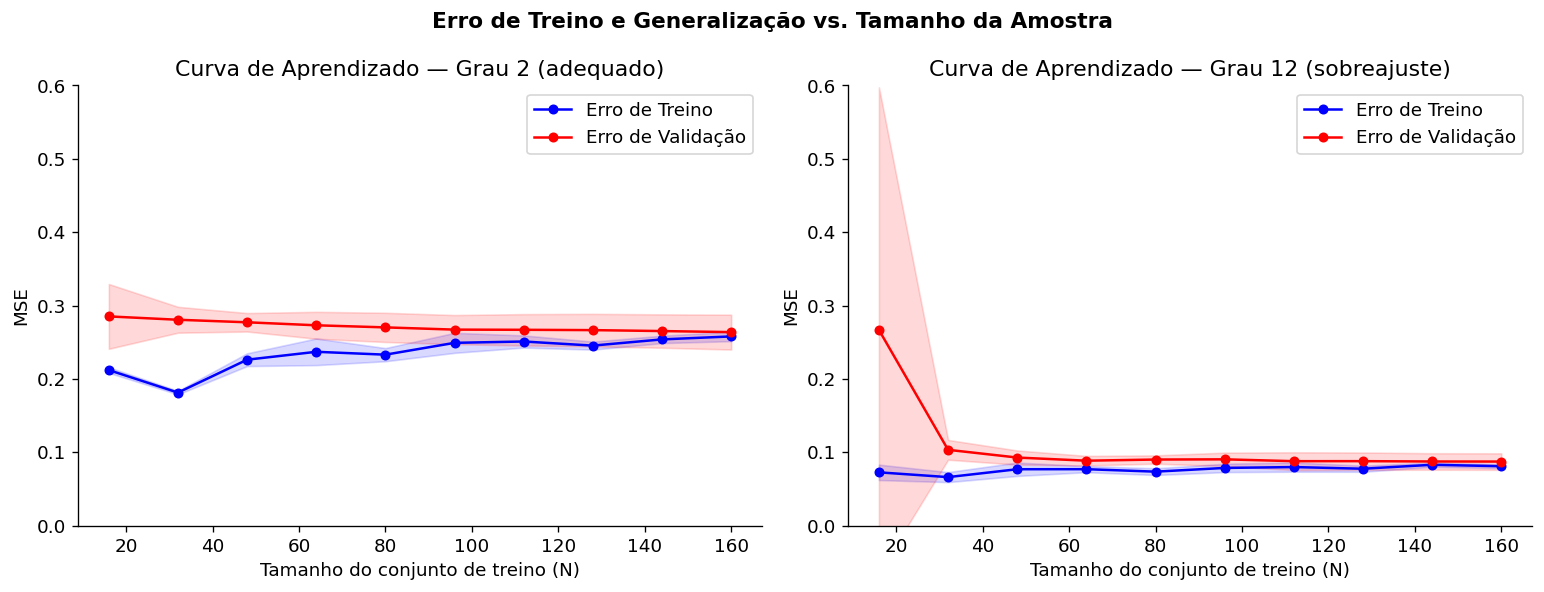

In [8]:
# --- Learning curves: training and generalization error vs. N ---
from sklearn.model_selection import learning_curve

np.random.seed(0)
N_total = 200
X_lc = np.random.uniform(0, 1, N_total).reshape(-1, 1)
y_lc = np.sin(2 * np.pi * X_lc.ravel()) + np.random.normal(0, 0.3, N_total)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, deg, ttl in zip(axes, [2, 12], ['Degree 2 (good fit)', 'Degree 12 (overfitting)']):
    model = make_pipeline(PolynomialFeatures(deg), Ridge(alpha=1e-4))
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=0)
    
    train_mean = -train_scores.mean(axis=1)
    val_mean = -val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 'b-o', ms=5, label='Training Error')
    ax.plot(train_sizes, val_mean, 'r-o', ms=5, label='Validation Error')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    ax.set_title(f'Learning Curve — {ttl}')
    ax.set_xlabel('Training set size (N)')
    ax.set_ylabel('MSE')
    ax.set_ylim(0, 0.6)
    ax.legend()

plt.suptitle('Training and Generalization Error vs. Sample Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Bayes Error

### 6.1 Definition

The **Bayes error** $R^*$ is the **smallest possible error** of any classifier/regressor, determined by the data-generating distribution — not by the chosen model.

$$R^* = \min_{f} R(f) = \mathbb{E}_{\mathbf{x}} \left[ \min_{y} \sum_{y'} \ell(y', y)\,p(y' \mid \mathbf{x}) \right]$$

For **binary classification with 0-1 loss**:

$$R^* = \mathbb{E}_{\mathbf{x}} \!\left[1 - \max_{k} p(y=k \mid \mathbf{x})\right]$$

The **Bayes-optimal classifier** is:

$$f^*(\mathbf{x}) = \arg\max_{k}\; p(y=k \mid \mathbf{x})$$

### 6.2 Sources of Error

The total error of a model can be decomposed as:

$$R(f) = R^* + \underbrace{(R(f) - R^*)}_{\text{excess risk}}$$

The excess risk comes from:
1. **Approximation error**: the space $\mathcal{F}$ does not contain $f^*$
2. **Estimation error**: finite data and imperfect optimization

> The Bayes error is **irreducible**: it stems from the noise intrinsic to the problem (features insufficient to determine $y$ with certainty).


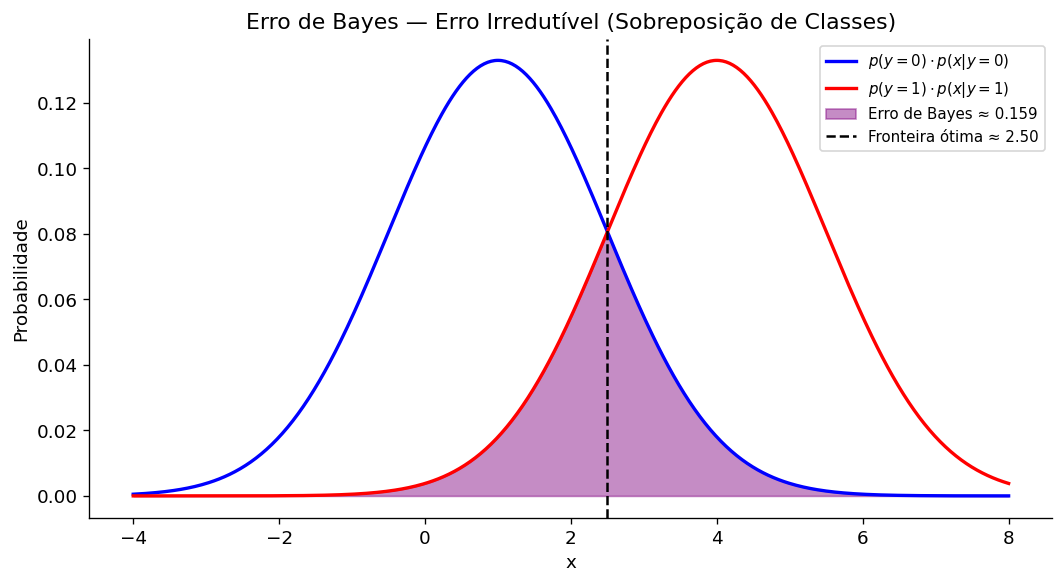

Erro de Bayes (erro irredutível): 0.1587


In [10]:
# --- Visualizing the Bayes Error ---

x_range = np.linspace(-4, 8, 500)

# Two classes with overlapping distributions
mu0, sigma0 = 1.0, 1.5
mu1, sigma1 = 4.0, 1.5
prior0, prior1 = 0.5, 0.5

p_x_c0 = stats.norm.pdf(x_range, mu0, sigma0)
p_x_c1 = stats.norm.pdf(x_range, mu1, sigma1)
p_x = prior0 * p_x_c0 + prior1 * p_x_c1

# Bayes boundary
x_boundary = (mu0 + mu1) / 2 + (sigma0**2 / (mu1 - mu0)) * np.log((prior1 * sigma0) / (prior0 * sigma1))

# Bayes error = overlap area (where the wrong class has higher probability)
bayes_error = np.trapezoid(np.minimum(prior0 * p_x_c0, prior1 * p_x_c1), x_range)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_range, prior0 * p_x_c0, 'b-', lw=2, label='$p(y=0)\\cdot p(x|y=0)$')
ax.plot(x_range, prior1 * p_x_c1, 'r-', lw=2, label='$p(y=1)\\cdot p(x|y=1)$')

# Irreducible error region
overlap = np.minimum(prior0 * p_x_c0, prior1 * p_x_c1)
ax.fill_between(x_range, 0, overlap, alpha=0.45, color='purple',
                label=f'Bayes error ≈ {bayes_error:.3f}')

ax.axvline(x_boundary, color='black', ls='--', lw=1.5, label=f'Optimal boundary ≈ {x_boundary:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('Probability')
ax.set_title('Bayes Error — Irreducible Error (Class Overlap)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Bayes error (irreducible error): {bayes_error:.4f}')

In [ ]:
# --- Overlap effect: Bayes error vs. class distance ---

separations = np.linspace(0, 6, 100)
bayes_errors = []

for sep in separations:
    p0 = stats.norm.pdf(x_range, 0, 1)
    p1 = stats.norm.pdf(x_range, sep, 1)
    be = np.trapezoid(np.minimum(0.5 * p0, 0.5 * p1), x_range)
    bayes_errors.append(be)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(separations, bayes_errors, 'purple', lw=2.5)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('Class separation (|μ₁ − μ₀|/σ)')
ax.set_ylabel('Bayes error')
ax.set_title('Bayes error decreases as classes separate')
ax.fill_between(separations, bayes_errors, alpha=0.2, color='purple')
plt.tight_layout()
plt.show()

---
## 7. Parameter Estimation, Bias and Variance

### 7.1 Estimators

An **estimator** $\hat{\theta}$ is a function of the data $\hat{\theta} = g(\mathcal{D})$ used to infer an unknown parameter $\theta^*$.

**Bias:**

$$\text{Bias}[\hat{\theta}] = \mathbb{E}[\hat{\theta}] - \theta^*$$

- If $\text{Bias}[\hat{\theta}] = 0$, the estimator is **unbiased**.

**Variance:**

$$\text{Var}[\hat{\theta}] = \mathbb{E}\!\left[(\hat{\theta} - \mathbb{E}[\hat{\theta}])^2\right]$$

**Mean Squared Error (MSE):**

$$\text{MSE}[\hat{\theta}] = \mathbb{E}\!\left[(\hat{\theta} - \theta^*)^2\right] = \text{Bias}[\hat{\theta}]^2 + \text{Var}[\hat{\theta}]$$

### 7.2 Consistency

An estimator is **consistent** if $\hat{\theta} \xrightarrow{p} \theta^*$ as $N \to \infty$.


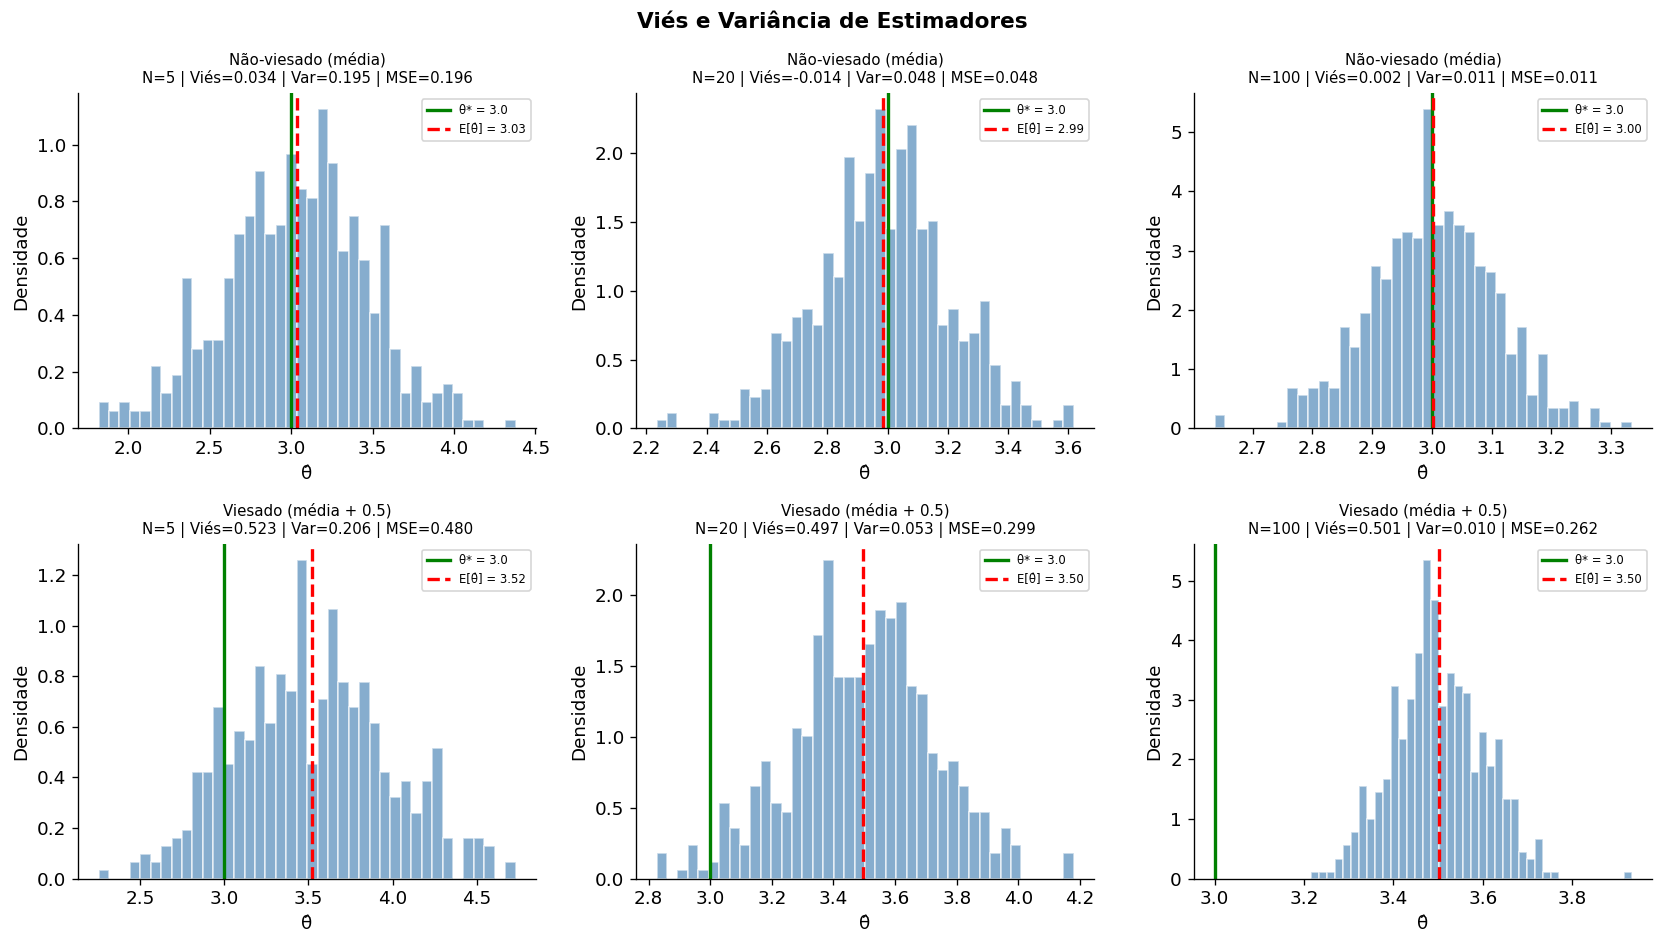

In [11]:
# --- Illustration: bias and variance of estimators ---

np.random.seed(42)
theta_true = 3.0
n_experiments = 500
sample_sizes = [5, 20, 100]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Unbiased estimator: sample mean
# Biased estimator: sample mean + deliberate constant
estimators = {
    'Unbiased (mean)': lambda x: np.mean(x),
    'Biased (mean + 0.5)': lambda x: np.mean(x) + 0.5,
}

for row, (est_name, estimator) in enumerate(estimators.items()):
    for col, n in enumerate(sample_sizes):
        estimates = [estimator(np.random.normal(theta_true, 1, n)) for _ in range(n_experiments)]
        bias = np.mean(estimates) - theta_true
        variance = np.var(estimates)
        mse = bias**2 + variance
        
        ax = axes[row, col]
        ax.hist(estimates, bins=40, density=True, alpha=0.65, color='steelblue', edgecolor='white')
        ax.axvline(theta_true, color='green', lw=2, label=f'θ* = {theta_true}')
        ax.axvline(np.mean(estimates), color='red', lw=2, ls='--', label=f'E[θ̂] = {np.mean(estimates):.2f}')
        ax.set_title(f'{est_name}\nN={n} | Bias={bias:.3f} | Var={variance:.3f} | MSE={mse:.3f}', fontsize=9)
        ax.legend(fontsize=7)
        ax.set_xlabel('θ̂'); ax.set_ylabel('Density')

plt.suptitle('Bias and Variance of Estimators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Sample Variance: biased vs. unbiased estimator

**Biased sample variance** (dividing by $N$):
$$\tilde{s}^2 = \frac{1}{N} \sum_{i=1}^{N}(x_i - \bar{x})^2 \qquad \Rightarrow \mathbb{E}[\tilde{s}^2] = \frac{N-1}{N}\sigma^2$$

**Unbiased sample variance** (dividing by $N-1$, Bessel's correction):
$$s^2 = \frac{1}{N-1} \sum_{i=1}^{N}(x_i - \bar{x})^2 \qquad \Rightarrow \mathbb{E}[s^2] = \sigma^2$$


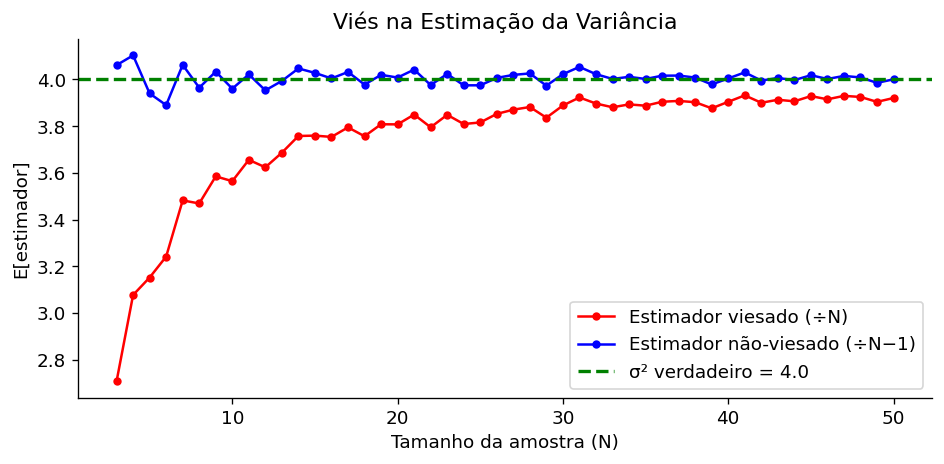

In [12]:
# --- Sample variance: biased vs. unbiased ---

sigma_true = 2.0
sample_sizes_v = range(3, 51)
n_reps = 2000

biased_var = []
unbiased_var = []

for n in sample_sizes_v:
    samples = np.random.normal(0, sigma_true, (n_reps, n))
    biased_var.append(np.mean(np.var(samples, axis=1, ddof=0)))
    unbiased_var.append(np.mean(np.var(samples, axis=1, ddof=1)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sample_sizes_v, biased_var, 'r-o', ms=4, label='Biased estimator (÷N)')
ax.plot(sample_sizes_v, unbiased_var, 'b-o', ms=4, label='Unbiased estimator (÷N−1)')
ax.axhline(sigma_true**2, color='green', ls='--', lw=2, label=f'true σ² = {sigma_true**2}')
ax.set_xlabel('Sample size (N)')
ax.set_ylabel('E[estimator]')
ax.set_title('Bias in Variance Estimation')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Relating Model Error, Bias and Variance

### 8.1 Bias-Variance Decomposition

For a regression problem with target function $f^*(\mathbf{x})$ and noise $\varepsilon \sim \mathcal{N}(0, \sigma_\varepsilon^2)$:

$$\mathbb{E}\!\left[\left(y - \hat{f}(\mathbf{x})\right)^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(\mathbf{x})] - f^*(\mathbf{x})\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\!\left[\left(\hat{f}(\mathbf{x}) - \mathbb{E}[\hat{f}(\mathbf{x})]\right)^2\right]}_{\text{Variance}} + \underbrace{\sigma_\varepsilon^2}_{\text{Irreducible error}}$$

$$\boxed{\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma_\varepsilon^2}$$

### 8.2 Bias-Variance Trade-off

| Complexity | Bias | Variance | Behavior |
|---|---|---|---|
| Low | High | Low | Underfitting |
| Ideal | Low | Low | Good generalization |
| High | Low | High | Overfitting |

As complexity increases:
- Bias decreases (model fits better)
- Variance increases (model more sensitive to the training data)

The goal is to find the complexity that **minimizes the total MSE**.


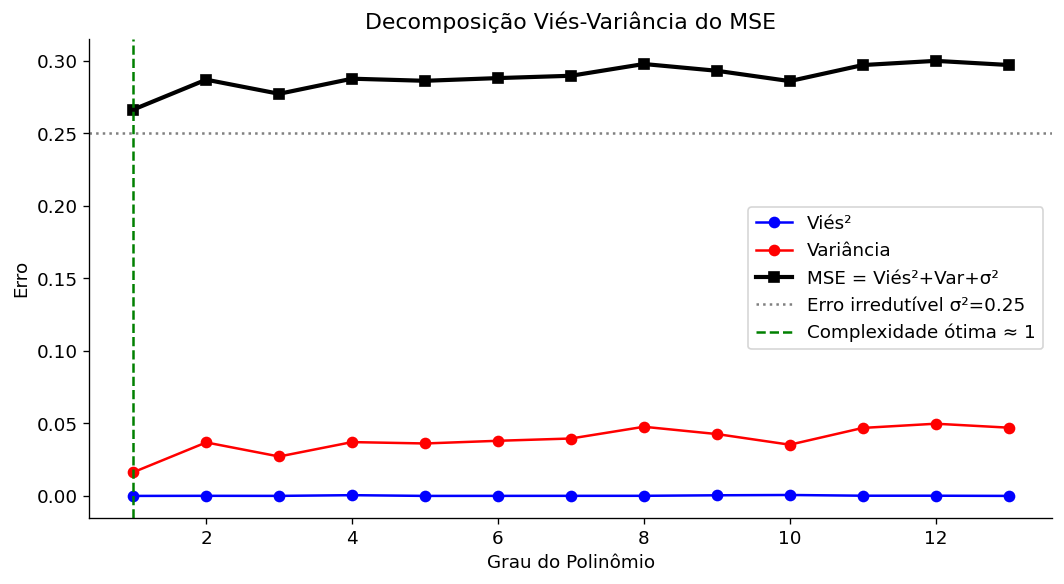

In [13]:
# --- Bias-Variance Decomposition via Bootstrap ---

np.random.seed(0)
sigma_eps = 0.5
x_eval = np.array([0.5])  # fixed evaluation point
n_datasets = 200
n_train_bv = 25

degrees_bv = range(1, 14)
bias2_list, var_list, mse_list = [], [], []

f_true_val = np.sin(2 * np.pi * x_eval[0])

for deg in degrees_bv:
    preds = []
    for _ in range(n_datasets):
        X_b = np.random.uniform(0, 1, n_train_bv)
        y_b = np.sin(2 * np.pi * X_b) + np.random.normal(0, sigma_eps, n_train_bv)
        m = make_pipeline(PolynomialFeatures(deg), Ridge(alpha=1e-5))
        m.fit(X_b.reshape(-1, 1), y_b)
        preds.append(m.predict(x_eval.reshape(-1, 1))[0])
    
    preds = np.array(preds)
    mean_pred = np.mean(preds)
    bias2 = (mean_pred - f_true_val) ** 2
    variance = np.var(preds)
    mse_total = bias2 + variance + sigma_eps**2
    
    bias2_list.append(bias2)
    var_list.append(variance)
    mse_list.append(mse_total)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees_bv, bias2_list, 'b-o', ms=6, label='Bias²')
ax.plot(degrees_bv, var_list, 'r-o', ms=6, label='Variance')
ax.plot(degrees_bv, mse_list, 'k-s', ms=6, lw=2.5, label='MSE = Bias²+Var+σ²')
ax.axhline(sigma_eps**2, color='gray', ls=':', lw=1.5, label=f'Irreducible error σ²={sigma_eps**2}')
best_deg = degrees_bv[np.argmin(mse_list)]
ax.axvline(best_deg, color='green', ls='--', lw=1.5, label=f'Optimal complexity ≈ {best_deg}')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Decomposition of the MSE')
ax.legend()
plt.tight_layout()
plt.show()

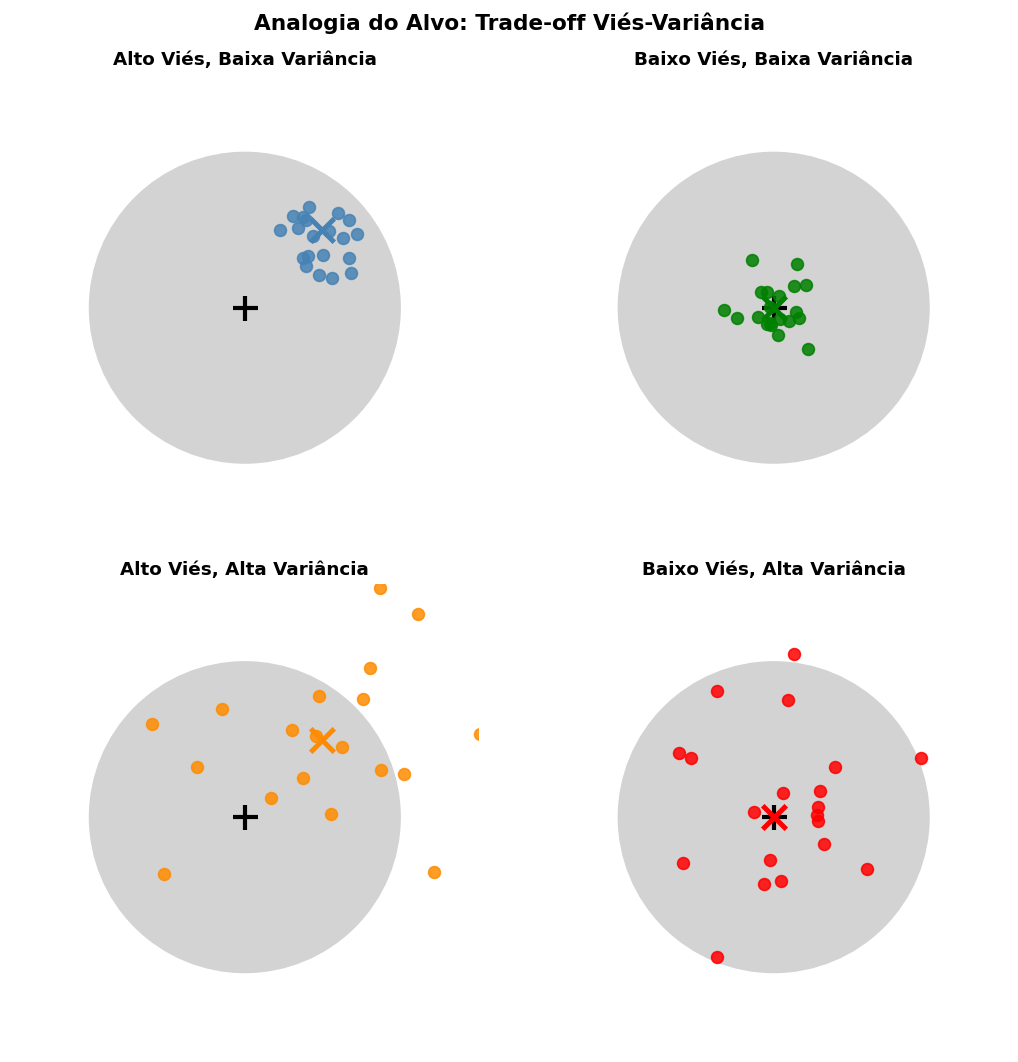

In [14]:
# --- Intuitive visualization: shooting targets ---

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
configs = [
    ('High Bias, Low Variance',  [0.5, 0.5],  0.15, 'steelblue'),
    ('Low Bias, Low Variance', [0.0, 0.0],  0.15, 'green'),
    ('High Bias, High Variance',   [0.5, 0.5],  0.5,  'darkorange'),
    ('Low Bias, High Variance',  [0.0, 0.0],  0.5,  'red'),
]

for ax, (title, center, spread, color) in zip(axes.ravel(), configs):
    # Target
    for r, alpha in [(1.0, 0.08), (0.7, 0.1), (0.4, 0.15), (0.15, 0.25)]:
        circle = plt.Circle((0, 0), r, color='lightgray', fill=True)
        ax.add_patch(circle)
    ax.plot(0, 0, 'k+', ms=15, mew=2.5)
    
    # Shots
    pts = np.random.normal(center, spread, (20, 2))
    ax.scatter(pts[:, 0], pts[:, 1], color=color, s=50, zorder=5, alpha=0.85)
    ax.scatter(*center, color=color, s=200, marker='x', lw=3, zorder=6)
    
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Target Analogy: Bias-Variance Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Maximum Likelihood Estimation (MLE)

### 9.1 Principle

Given a parametric model $p(\mathbf{x}; \boldsymbol{\theta})$ and an i.i.d. sample $\mathcal{D} = \{\mathbf{x}^{(i)}\}_{i=1}^N$, the **likelihood function** is:

$$L(\boldsymbol{\theta}; \mathcal{D}) = p(\mathcal{D}; \boldsymbol{\theta}) = \prod_{i=1}^{N} p(\mathbf{x}^{(i)}; \boldsymbol{\theta})$$

The **Maximum Likelihood Estimator (MLE)** is:

$$\hat{\boldsymbol{\theta}}_{\text{MLE}} = \arg\max_{\boldsymbol{\theta}} L(\boldsymbol{\theta}; \mathcal{D}) = \arg\max_{\boldsymbol{\theta}} \sum_{i=1}^{N} \log p(\mathbf{x}^{(i)}; \boldsymbol{\theta})$$

(We use the **log-likelihood** $\ell(\boldsymbol{\theta}) = \log L(\boldsymbol{\theta})$ for numerical convenience.)

### 9.2 Properties of the MLE

1. **Consistency**: $\hat{\boldsymbol{\theta}}_{\text{MLE}} \xrightarrow{p} \boldsymbol{\theta}^*$ as $N \to \infty$
2. **Asymptotic efficiency**: attains the Cramér-Rao lower bound
3. **Invariance**: if $\hat{\boldsymbol{\theta}}$ is the MLE of $\boldsymbol{\theta}$, then $g(\hat{\boldsymbol{\theta}})$ is the MLE of $g(\boldsymbol{\theta})$

### 9.3 Analytical Examples

**Gaussian** $\mathcal{N}(\mu, \sigma^2)$:

$$\hat{\mu}_{\text{MLE}} = \frac{1}{N}\sum_i x_i \qquad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{N}\sum_i (x_i - \hat{\mu})^2$$

**Bernoulli** $\text{Ber}(p)$:

$$\hat{p}_{\text{MLE}} = \frac{1}{N}\sum_i x_i = \bar{x}$$


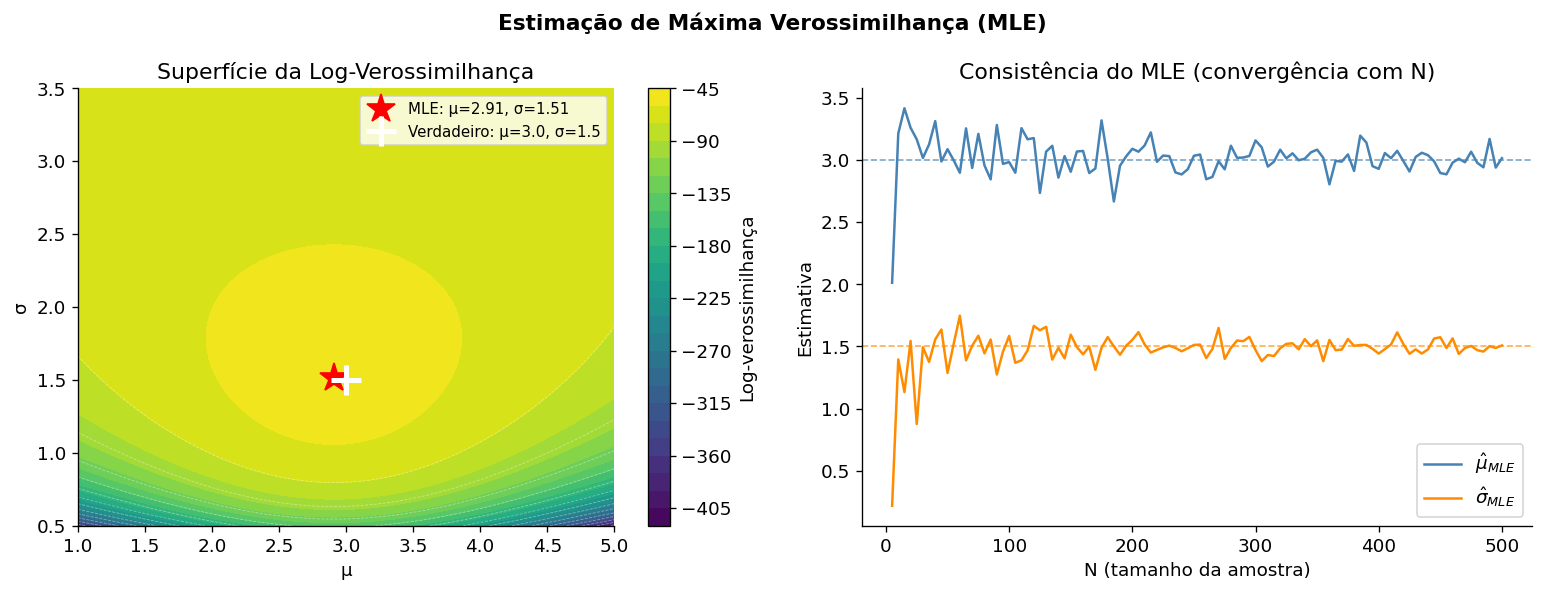

In [15]:
# --- MLE for the Normal distribution: likelihood surface ---

np.random.seed(1)
mu_true, sigma_true_mle = 3.0, 1.5
data_mle = np.random.normal(mu_true, sigma_true_mle, 30)

mu_grid = np.linspace(1, 5, 200)
sigma_grid = np.linspace(0.5, 3.5, 200)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

log_lik = np.zeros_like(MU)
for i in range(len(mu_grid)):
    for j in range(len(sigma_grid)):
        log_lik[j, i] = np.sum(stats.norm.logpdf(data_mle, MU[j, i], SIGMA[j, i]))

mu_mle = np.mean(data_mle)
sigma_mle = np.std(data_mle)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log-likelihood surface
cf = axes[0].contourf(MU, SIGMA, log_lik, levels=30, cmap='viridis')
plt.colorbar(cf, ax=axes[0], label='Log-likelihood')
axes[0].contour(MU, SIGMA, log_lik, levels=15, colors='white', linewidths=0.5, alpha=0.4)
axes[0].plot(mu_mle, sigma_mle, 'r*', ms=18, label=f'MLE: μ={mu_mle:.2f}, σ={sigma_mle:.2f}')
axes[0].plot(mu_true, sigma_true_mle, 'w+', ms=18, mew=3, label=f'True: μ={mu_true}, σ={sigma_true_mle}')
axes[0].set_xlabel('μ'); axes[0].set_ylabel('σ')
axes[0].set_title('Log-Likelihood Surface')
axes[0].legend(fontsize=9)

# MLE convergence with N
N_values = np.arange(5, 501, 5)
mu_mle_n, sigma_mle_n = [], []
for n in N_values:
    d = np.random.normal(mu_true, sigma_true_mle, n)
    mu_mle_n.append(np.mean(d))
    sigma_mle_n.append(np.std(d))

axes[1].plot(N_values, mu_mle_n, 'steelblue', lw=1.5, label='$\\hat{μ}_{MLE}$')
axes[1].plot(N_values, sigma_mle_n, 'darkorange', lw=1.5, label='$\\hat{σ}_{MLE}$')
axes[1].axhline(mu_true, color='steelblue', ls='--', lw=1, alpha=0.7)
axes[1].axhline(sigma_true_mle, color='darkorange', ls='--', lw=1, alpha=0.7)
axes[1].set_xlabel('N (sample size)')
axes[1].set_ylabel('Estimate')
axes[1].set_title('MLE Consistency (convergence with N)')
axes[1].legend()

plt.suptitle('Maximum Likelihood Estimation (MLE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

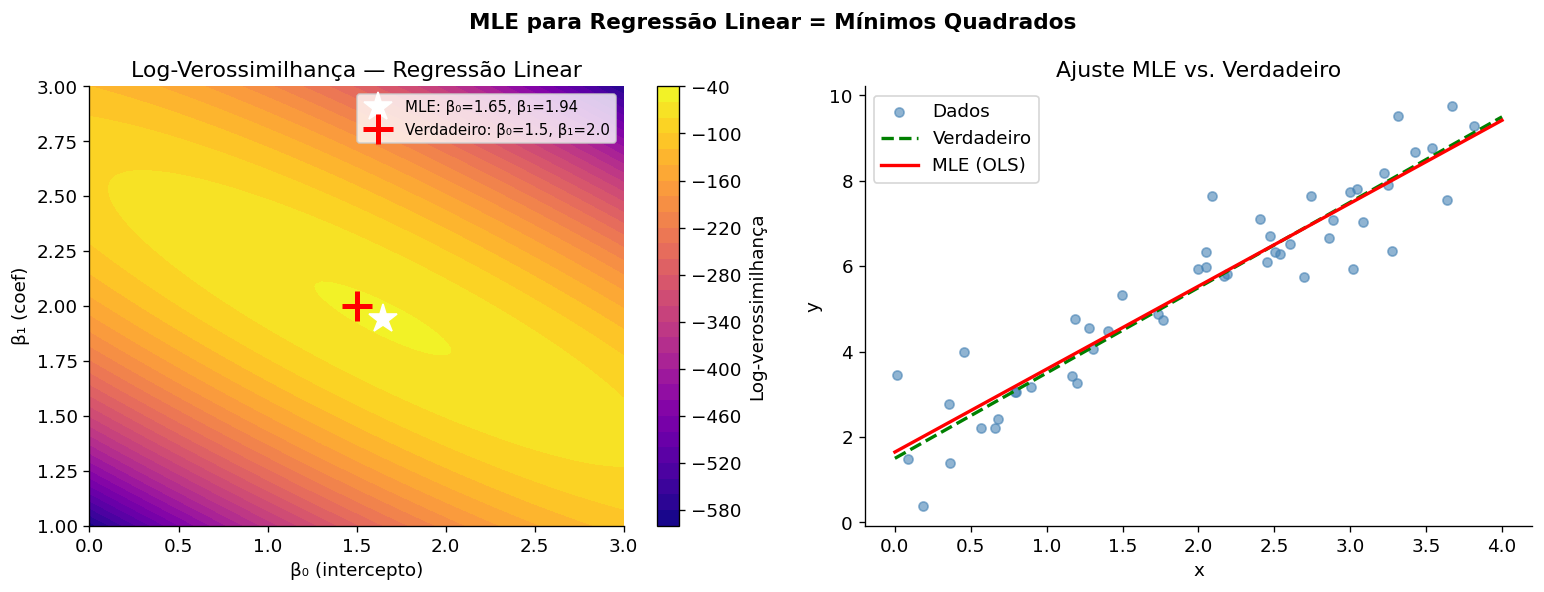

In [16]:
# --- MLE for Linear Regression (numerical derivation) ---

np.random.seed(10)
n_mle = 50
X_mle = np.random.uniform(0, 4, n_mle)
beta_true = np.array([1.5, 2.0])  # intercept, slope
sigma_reg = 0.8
y_mle = beta_true[0] + beta_true[1] * X_mle + np.random.normal(0, sigma_reg, n_mle)

# Parameter grid
b0_range = np.linspace(0, 3, 100)
b1_range = np.linspace(1, 3, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)

log_lik_reg = np.zeros_like(B0)
for i, b0 in enumerate(b0_range):
    for j, b1 in enumerate(b1_range):
        residuals = y_mle - (b0 + b1 * X_mle)
        log_lik_reg[j, i] = np.sum(stats.norm.logpdf(residuals, 0, sigma_reg))

# Analytical MLE (least squares)
X_mat = np.column_stack([np.ones(n_mle), X_mle])
beta_mle = np.linalg.lstsq(X_mat, y_mle, rcond=None)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cf = axes[0].contourf(B0, B1, log_lik_reg, levels=30, cmap='plasma')
plt.colorbar(cf, ax=axes[0], label='Log-likelihood')
axes[0].plot(*beta_mle, 'w*', ms=18, label=f'MLE: β₀={beta_mle[0]:.2f}, β₁={beta_mle[1]:.2f}')
axes[0].plot(*beta_true, 'r+', ms=18, mew=3, label=f'True: β₀={beta_true[0]}, β₁={beta_true[1]}')
axes[0].set_xlabel('β₀ (intercept)'); axes[0].set_ylabel('β₁ (slope)')
axes[0].set_title('Log-Likelihood — Linear Regression')
axes[0].legend(fontsize=9)

x_line = np.linspace(0, 4, 100)
axes[1].scatter(X_mle, y_mle, alpha=0.6, s=30, label='Data', color='steelblue')
axes[1].plot(x_line, beta_true[0] + beta_true[1]*x_line, 'g--', lw=2, label='True')
axes[1].plot(x_line, beta_mle[0] + beta_mle[1]*x_line, 'r-', lw=2, label='MLE (OLS)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('MLE Fit vs. True')
axes[1].legend()

plt.suptitle('MLE for Linear Regression = Least Squares', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Bayesian Statistics

### 10.1 The Bayesian Principle

In the **Bayesian** approach, the parameters $\boldsymbol{\theta}$ are treated as **random variables** with a probability distribution, unlike the frequentist approach (where they are fixed unknown constants).

Applying Bayes' rule:

$$\underbrace{p(\boldsymbol{\theta} \mid \mathcal{D})}_{\text{posterior}} = \frac{\overbrace{p(\mathcal{D} \mid \boldsymbol{\theta})}^{\text{likelihood}} \cdot \overbrace{p(\boldsymbol{\theta})}^{\text{prior}}}{\underbrace{p(\mathcal{D})}_{\text{evidence}}}$$

### 10.2 MAP Estimator

The **Maximum a Posteriori (MAP)** estimator maximizes the posterior:

$$\hat{\boldsymbol{\theta}}_{\text{MAP}} = \arg\max_{\boldsymbol{\theta}} \log p(\mathcal{D} \mid \boldsymbol{\theta}) + \log p(\boldsymbol{\theta})$$

**MLE-MAP-Regularization connection:**
- Gaussian prior $p(\boldsymbol{\theta}) = \mathcal{N}(0, \tau^2 I)$ → MAP = **Ridge** ($L_2$)
- Laplacian prior $p(\boldsymbol{\theta}) \propto e^{-\lambda|\theta|}$ → MAP = **Lasso** ($L_1$)
- Uniform prior → MAP = **MLE**

### 10.3 Full Bayesian Inference

Instead of a single point estimate, full Bayesian inference uses the entire **posterior distribution** to make predictions:

$$p(y^* \mid \mathbf{x}^*, \mathcal{D}) = \int p(y^* \mid \mathbf{x}^*, \boldsymbol{\theta}) \, p(\boldsymbol{\theta} \mid \mathcal{D}) \, d\boldsymbol{\theta}$$

### 10.4 Conjugate Priors

A prior is **conjugate** when the posterior belongs to the same functional family as the prior.
Classic examples:
- Binomial likelihood + **Beta** prior → **Beta** posterior
- Normal likelihood + **Normal** prior → **Normal** posterior


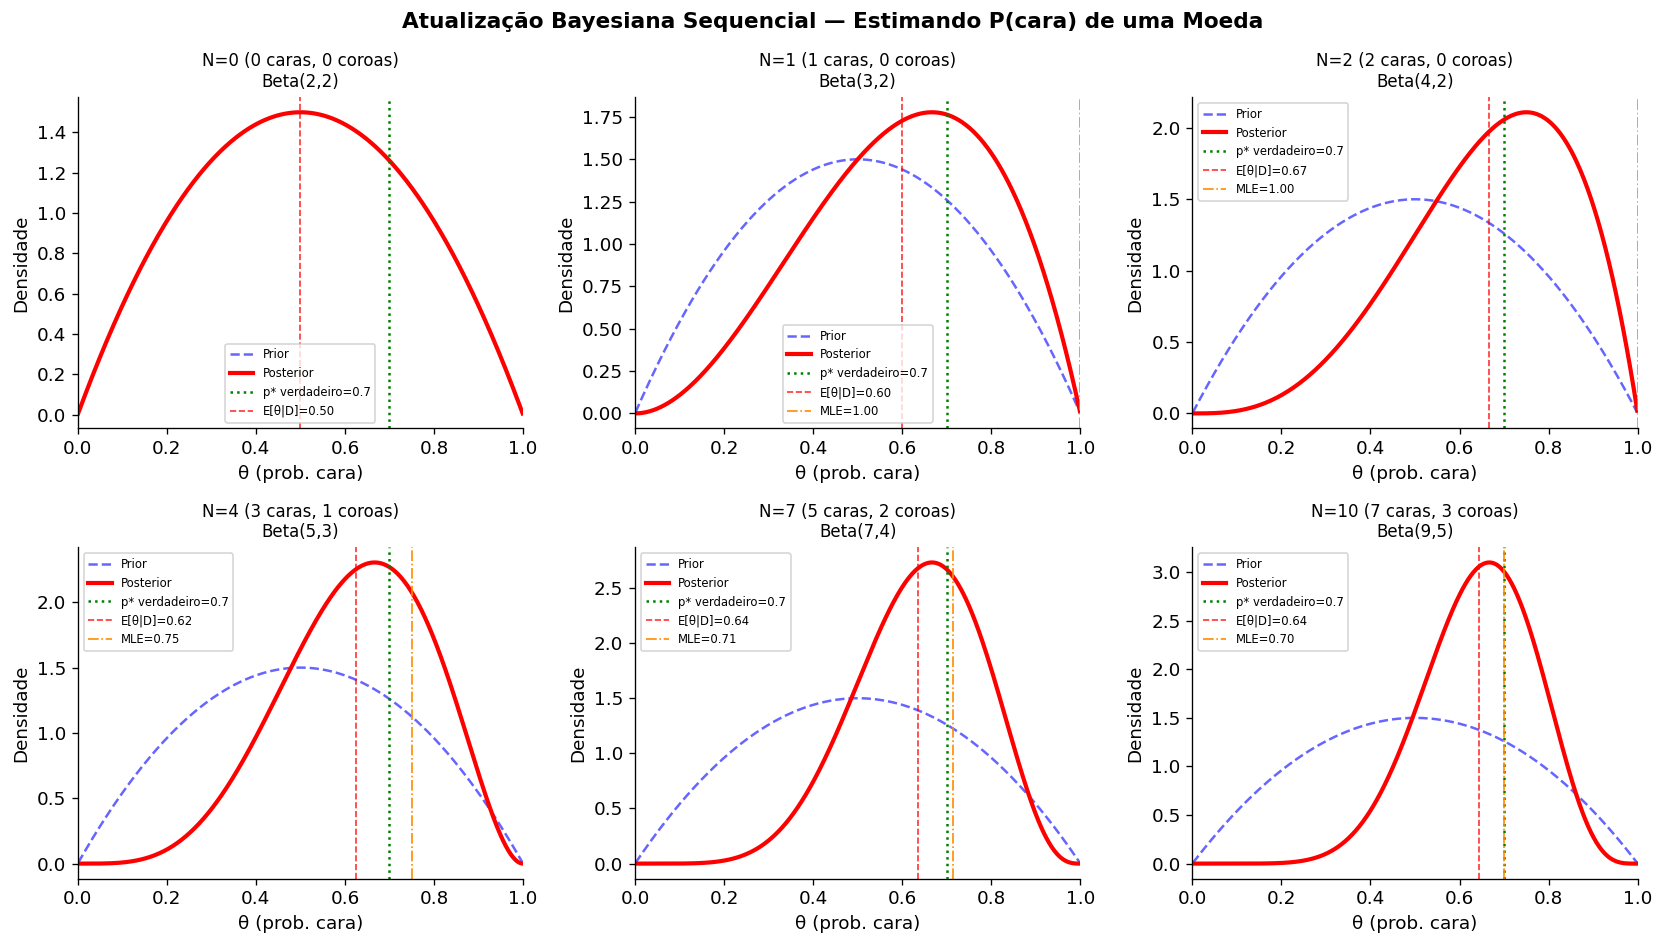

In [17]:
# --- Bayesian Update: Beta Prior + Binomial ---

theta_range = np.linspace(0.001, 0.999, 500)

# Prior: Beta(2, 2) — mild belief in p≈0.5
alpha_prior, beta_prior = 2, 2

# Observed data (heads = 1)
observations = [1, 1, 0, 1, 0, 1, 1, 1, 0, 1]  # 7 heads, 3 tails

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.ravel()

alpha_curr, beta_curr = alpha_prior, beta_prior
snapshots = [0, 1, 2, 4, 7, len(observations)]

for idx, n_obs in enumerate(snapshots):
    ax = axes_flat[idx]
    
    heads = sum(observations[:n_obs])
    tails = n_obs - heads
    alpha_post = alpha_prior + heads
    beta_post = beta_prior + tails
    
    prior_pdf = stats.beta.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf = stats.beta.pdf(theta_range, alpha_post, beta_post)
    
    map_est = (alpha_post - 1) / (alpha_post + beta_post - 2) if (alpha_post + beta_post) > 2 else 0.5
    mean_post = alpha_post / (alpha_post + beta_post)
    mle = heads / n_obs if n_obs > 0 else 0.5
    
    ax.plot(theta_range, prior_pdf, 'b--', lw=1.5, alpha=0.6, label='Prior')
    ax.plot(theta_range, post_pdf, 'r-', lw=2.5, label='Posterior')
    ax.axvline(0.7, color='green', ls=':', lw=1.5, label='true p*=0.7')
    ax.axvline(mean_post, color='red', ls='--', lw=1, alpha=0.8, label=f'E[θ|D]={mean_post:.2f}')
    if n_obs > 0:
        ax.axvline(mle, color='darkorange', ls='-.', lw=1, label=f'MLE={mle:.2f}')
    
    ax.set_title(f'N={n_obs} ({heads} heads, {tails} tails)\nBeta({alpha_post},{beta_post})', fontsize=10)
    ax.set_xlabel('θ (prob. heads)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

plt.suptitle('Sequential Bayesian Update — Estimating a Coin\'s P(heads)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

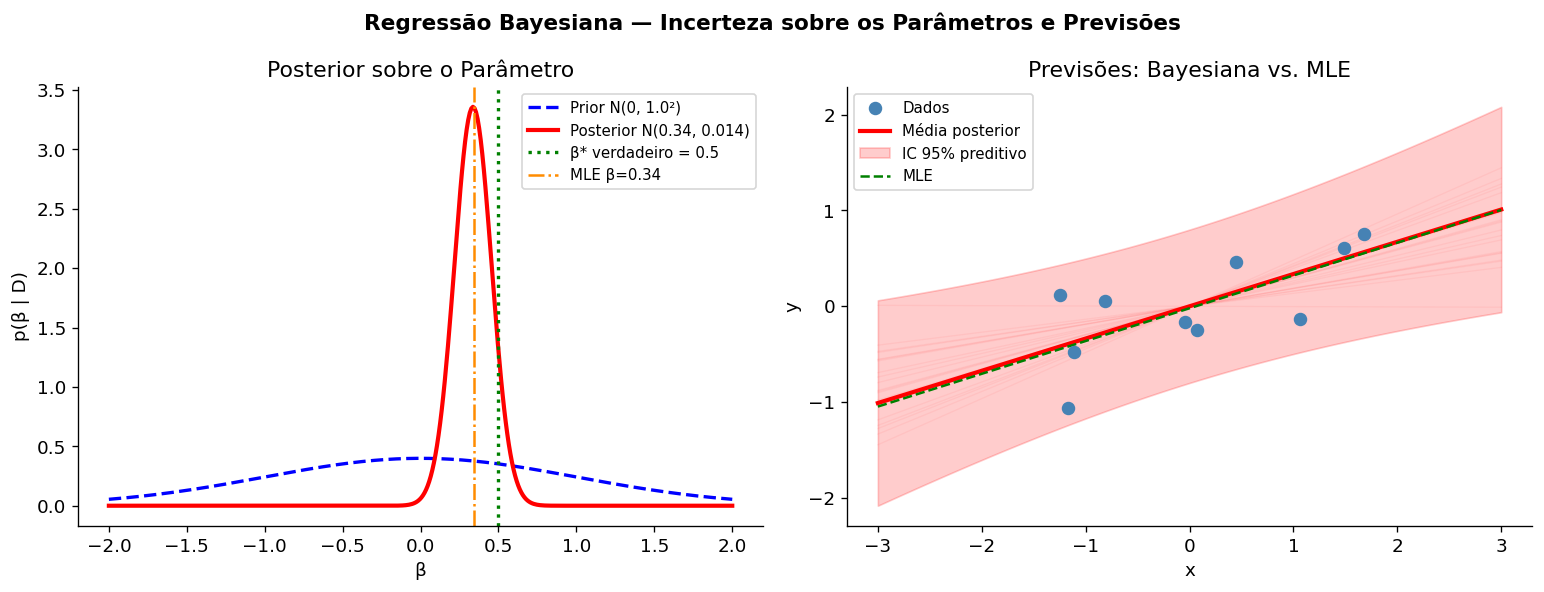

In [18]:
# --- Bayesian Regression vs. MLE: predictive uncertainty ---

np.random.seed(5)
n_bayes = 10
sigma_noise_b = 0.4
tau_prior = 1.0  # prior std over parameters

X_b = np.random.uniform(-2, 2, n_bayes)
y_b = 0.5 * X_b + np.random.normal(0, sigma_noise_b, n_bayes)

X_plot = np.linspace(-3, 3, 200)

# --- MLE estimate (point) ---
X_mat_b = np.column_stack([np.ones(n_bayes), X_b])
beta_ols = np.linalg.lstsq(X_mat_b, y_b, rcond=None)[0]

# --- Analytical posterior (Normal-Normal conjugate) ---
# Model: y = β₁*x, parameter β₁, prior ~ N(0, τ²)
prior_var = tau_prior**2
noise_var = sigma_noise_b**2
post_var = 1.0 / (1.0/prior_var + np.sum(X_b**2)/noise_var)
post_mean = post_var * (np.sum(X_b * y_b) / noise_var)

# Posterior samples
n_samples = 200
beta_samples = np.random.normal(post_mean, np.sqrt(post_var), n_samples)
y_samples = np.outer(beta_samples, X_plot)  # (n_samples, n_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Posterior over the parameter
theta_plot = np.linspace(-2, 2, 400)
axes[0].plot(theta_plot, stats.norm.pdf(theta_plot, 0, tau_prior),
             'b--', lw=2, label=f'Prior N(0, {tau_prior}²)')
axes[0].plot(theta_plot, stats.norm.pdf(theta_plot, post_mean, np.sqrt(post_var)),
             'r-', lw=2.5, label=f'Posterior N({post_mean:.2f}, {post_var:.3f})')
axes[0].axvline(0.5, color='green', ls=':', lw=2, label='true β* = 0.5')
axes[0].axvline(beta_ols[1], color='darkorange', ls='-.', lw=1.5, label=f'MLE β={beta_ols[1]:.2f}')
axes[0].set_xlabel('β'); axes[0].set_ylabel('p(β | D)')
axes[0].set_title('Posterior over the Parameter')
axes[0].legend(fontsize=9)

# Predictions
y_mean_post = post_mean * X_plot
y_std_post = np.sqrt(post_var * X_plot**2 + noise_var)

for s in y_samples[::10]:
    axes[1].plot(X_plot, s, 'r-', alpha=0.05, lw=0.8)

axes[1].scatter(X_b, y_b, s=50, color='steelblue', zorder=5, label='Data')
axes[1].plot(X_plot, y_mean_post, 'r-', lw=2.5, label='Posterior mean')
axes[1].fill_between(X_plot, y_mean_post - 2*y_std_post, y_mean_post + 2*y_std_post,
                     alpha=0.2, color='red', label='95% predictive CI')
axes[1].plot(X_plot, beta_ols[0] + beta_ols[1]*X_plot, 'g--', lw=1.5, label='MLE')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Predictions: Bayesian vs. MLE')
axes[1].legend(fontsize=9)

plt.suptitle('Bayesian Regression — Uncertainty over Parameters and Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

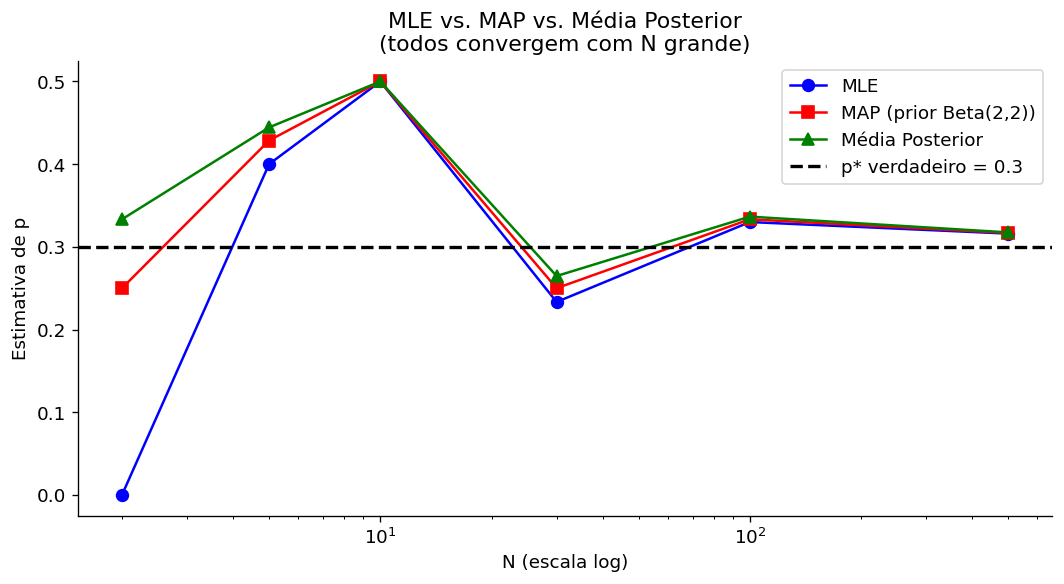


Comparação de estimativas:
     N |      MLE |      MAP |   E[θ|D]
----------------------------------------
     2 |   0.0000 |   0.2500 |   0.3333
     5 |   0.4000 |   0.4286 |   0.4444
    10 |   0.5000 |   0.5000 |   0.5000
    30 |   0.2333 |   0.2500 |   0.2647
   100 |   0.3300 |   0.3333 |   0.3365
   500 |   0.3160 |   0.3167 |   0.3175


In [19]:
# --- Comparison: MLE vs. MAP vs. Full Bayes ---

np.random.seed(99)
p_true_coin = 0.3  # biased coin
sample_sizes_comp = [2, 5, 10, 30, 100, 500]

mle_ests, map_ests, bayes_means = [], [], []
alpha_p, beta_p = 2, 2  # Beta(2,2) prior

for n in sample_sizes_comp:
    flips = np.random.binomial(1, p_true_coin, n)
    heads = flips.sum()
    tails = n - heads
    
    mle_ests.append(heads / n)
    ap = alpha_p + heads; bp = beta_p + tails
    map_ests.append((ap - 1) / (ap + bp - 2) if (ap + bp) > 2 else 0.5)
    bayes_means.append(ap / (ap + bp))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(sample_sizes_comp, mle_ests, 'b-o', ms=7, label='MLE')
ax.semilogx(sample_sizes_comp, map_ests, 'r-s', ms=7, label='MAP (prior Beta(2,2))')
ax.semilogx(sample_sizes_comp, bayes_means, 'g-^', ms=7, label='Posterior Mean')
ax.axhline(p_true_coin, color='black', ls='--', lw=2, label=f'true p* = {p_true_coin}')
ax.set_xlabel('N (log scale)')
ax.set_ylabel('Estimate of p')
ax.set_title('MLE vs. MAP vs. Posterior Mean\n(all converge for large N)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nComparison of estimates:')
print(f'{"N":>6} | {"MLE":>8} | {"MAP":>8} | {"E[θ|D]":>8}')
print('-' * 40)
for n, mle, map_, bayes in zip(sample_sizes_comp, mle_ests, map_ests, bayes_means):
    print(f'{n:>6} | {mle:>8.4f} | {map_:>8.4f} | {bayes:>8.4f}')

---
## 11. Synthesis: Concept Map

```
MACHINE LEARNING
│
├── Probabilistic Perspective
│   ├── p*(x, y): data-generating distribution
│   ├── Supervised: learns p(y|x; θ)
│   └── Unsupervised: learns p(x; θ)
│
├── Capacity and Fit
│   ├── Underfitting (high bias)
│   ├── Overfitting (high variance)
│   └── Regularization: λΩ(θ)
│
├── Errors and Bounds
│   ├── Training error: R̂(f) = mean loss
│   ├── Generalization error: R(f) = E[loss]
│   └── Bayes error R*: irreducible floor
│
├── Bias-Variance Decomposition
│   └── MSE = Bias² + Variance + σ²_ε
│
└── Parameter Estimation
    ├── MLE: max p(D|θ) → point estimate
    │   └── Uniform prior
    ├── MAP: max p(D|θ)·p(θ) → regularization
    │   ├── Gaussian prior → Ridge (L2)
    │   └── Laplacian prior → Lasso (L1)
    └── Full Bayes: p(θ|D) → posterior distribution
        └── With more data: MLE ≈ MAP ≈ E[θ|D]
```

---

## References

1. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning*. MIT Press. [deeplearningbook.org](https://www.deeplearningbook.org/)
2. **Bishop, C. M.** (2006). *Pattern Recognition and Machine Learning*. Springer.
3. **Murphy, K. P.** (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press.
4. **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
5. **Shalev-Shwartz, S. & Ben-David, S.** (2014). *Understanding Machine Learning: From Theory to Algorithms*. Cambridge University Press.
